In [1]:
import pandas as pd

# Load the CSV file for Kenya
df = pd.read_csv("D:\Aman\KAIM-9\Week-0\Week0-climate-challange\climate-challenge-week0\data\kenya.csv")

# Add a Country column
df["Country"] = "Kenya"

# Convert YEAR and DOY to a proper datetime column
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract Month as a separate column
df["Month"] = df["Date"].dt.month

df.tail()

<>:4: SyntaxWarning: invalid escape sequence '\A'
<>:4: SyntaxWarning: invalid escape sequence '\A'
C:\Users\a00928253\AppData\Local\Temp\ipykernel_7796\3272274486.py:4: SyntaxWarning: invalid escape sequence '\A'
  df = pd.read_csv("D:\Aman\KAIM-9\Week-0\Week0-climate-challange\climate-challenge-week0\data\kenya.csv")


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
4103,2026,86,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40,Kenya,2026-03-27,3
4104,2026,87,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68,Kenya,2026-03-28,3
4105,2026,88,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92,Kenya,2026-03-29,3
4106,2026,89,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16,Kenya,2026-03-30,3
4107,2026,90,19.59,25.54,15.37,10.17,1.29,80.88,2.15,3.58,83.92,13.40,Kenya,2026-03-31,3


In [2]:
import numpy as np

# Replace all -999 with np.nan
df = df.replace(-999, np.nan)

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Drop duplicates if any
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")

Number of duplicate rows: 0


In [3]:
# Run df.describe() on all numeric columns
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


In [4]:
# Check missing values
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100

# Create a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

# Filter columns with >5% missing
high_missing = missing_summary[missing_summary['Missing %'] > 5]
print("Columns with >5% missing values:")
print(high_missing)

# Show all missing values
print("\nAll columns with missing values:")
print(missing_summary[missing_summary['Missing Count'] > 0])

Columns with >5% missing values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

All columns with missing values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [5]:
from scipy.stats import zscore

cols = [
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "PRECTOTCORR",
    "RH2M",
    "WS2M",
    "WS2M_MAX"
]

z_scores = np.abs(df[cols].apply(zscore))

outliers = (z_scores > 3).sum()
print(outliers)

T2M             8
T2M_MAX         3
T2M_MIN         9
PRECTOTCORR    92
RH2M            6
WS2M            0
WS2M_MAX        6
dtype: int64


<Axes: xlabel='Date'>

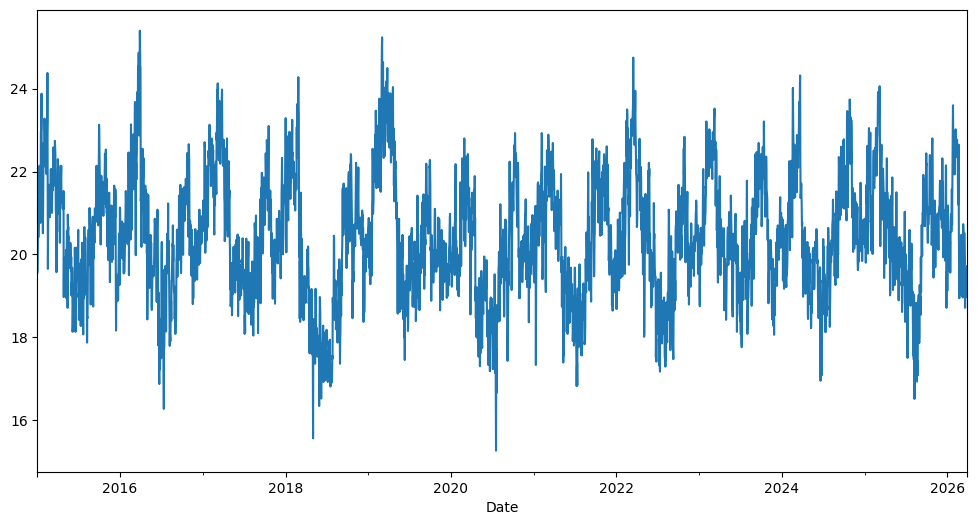

In [6]:
monthly_temp = df.groupby("Date")["T2M"].mean()

monthly_temp.plot(figsize=(12,6))

<Axes: xlabel='Month'>

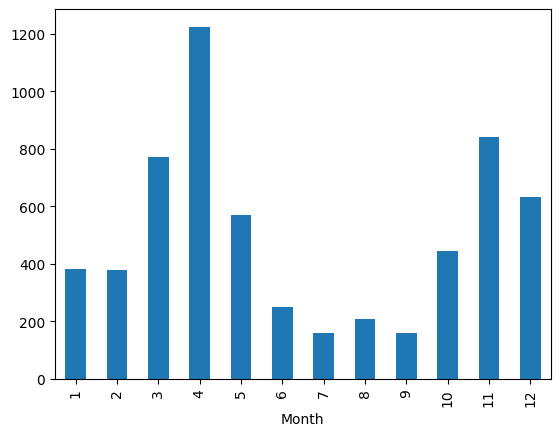

In [7]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")

<Axes: >

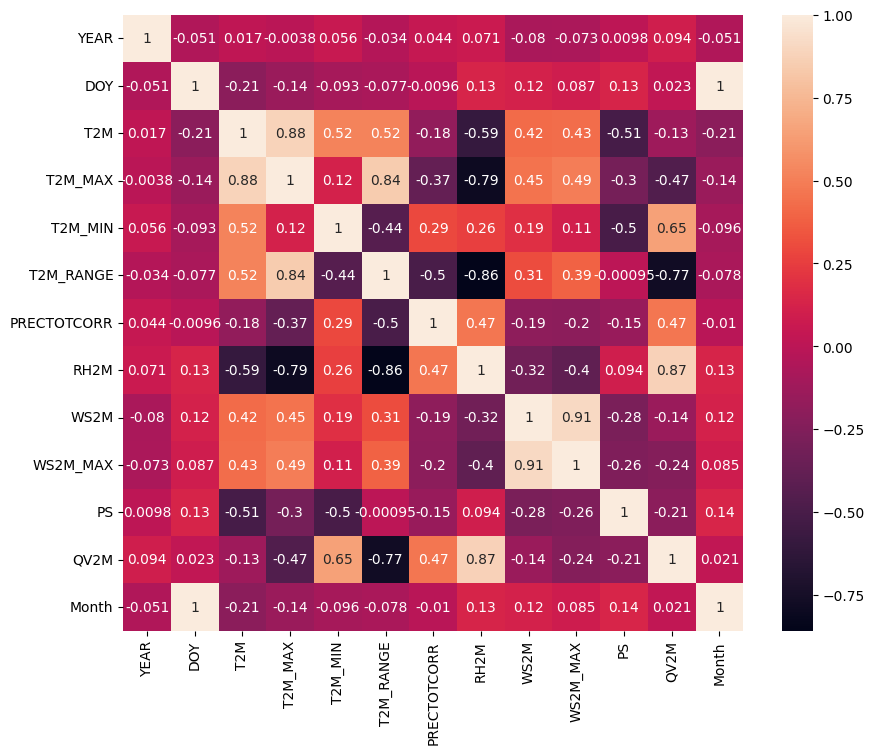

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)

<Axes: xlabel='T2M', ylabel='RH2M'>

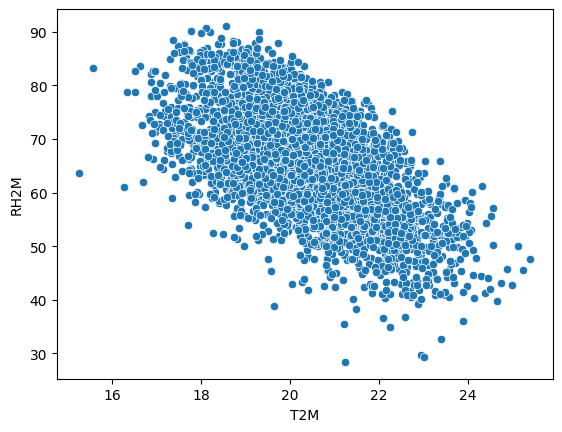

In [9]:
sns.scatterplot(data=df, x="T2M", y="RH2M")

<Axes: xlabel='T2M_RANGE', ylabel='WS2M'>

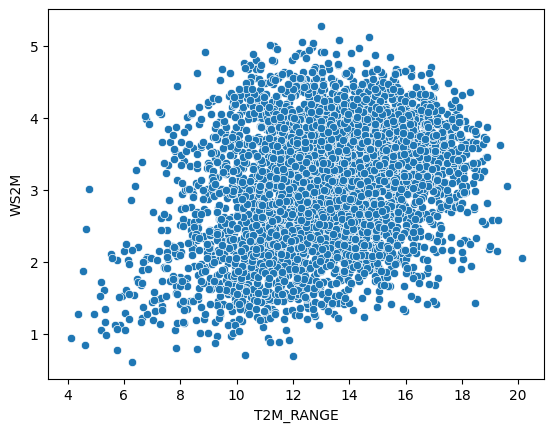

In [10]:
sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")

<Axes: xlabel='PRECTOTCORR', ylabel='Count'>

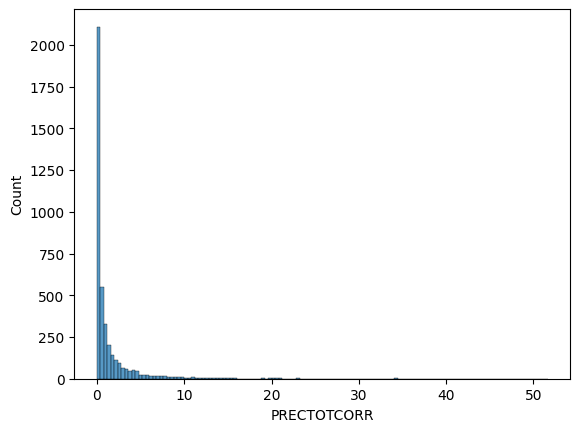

In [11]:
sns.histplot(df["PRECTOTCORR"])

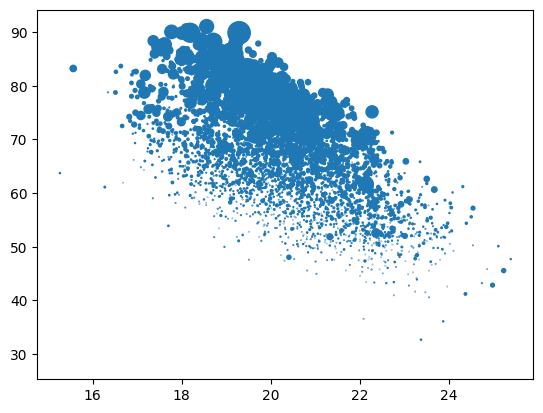

In [12]:
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"]*5
)